# TSP exact par ILP — TSPTW-D (OR-Tools CP-SAT, formulation MTZ + DFJ)

Résout le **TSP avec fenêtres temporelles cycliques et coûts dynamiques (perturbations)**
via ILP (CP-SAT d'OR-Tools), en reproduisant exactement la sémantique des contraintes
intégrées dans `LKH3Solver`.

| Contrainte | Modélisation ILP |
|---|---|
| **Fenêtres temporelles cycliques** `[a_i, b_i]` | Variables `tau_i` continues + attente modélisée via pénalité ou relaxation cyclique |
| **Coûts dynamiques (perturbations)** `c_ij(t) = base × alpha` | Coût de transit pré-calculé selon l'heure estimée de départ |

> **Limite MTZ :** fiable jusqu'à ~50 villes. Au-delà, utiliser la formulation DFJ avec lazy constraints.


In [2]:
import math
import json
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Optional
from ortools.sat.python import cp_model


## 1. Génération de graphe

In [3]:
def generate_graph(n: int, seed: int | None = None) -> list[tuple[float, float]]:
    """
    Génère n villes aléatoires dans [0, 1]² (coords normalisées, comme les datasets JSON).
    """
    rng = random.Random(seed)
    return [(rng.uniform(0, 1), rng.uniform(0, 1)) for _ in range(n)]


In [4]:
def load_json_instance(path: Path):
    """
    Charge un fichier tsptwd_n*.json (même format que le LKH-3).

    Retourne
    --------
    coords        : list[(x, y)]       — dépôt en index 0
    time_windows  : list[(a_i, b_i)]   — fenêtres temporelles
    service_times : list[float]        — s_i
    perturbations : list[dict]         — [{arc, t_start, t_end, alpha}]
    meta          : dict
    """
    with open(path) as f:
        data = json.load(f)

    nodes = [data["depot"]] + data["clients"]
    coords = [(nd["x"], nd["y"]) for nd in nodes]

    INF = float("inf")
    time_windows  = [
        (nd["a"] if nd["a"] is not None else 0.0,
         nd["b"] if nd["b"] is not None else INF)
        for nd in nodes
    ]
    service_times = [nd["service"] for nd in nodes]
    perturbations = data.get("perturbations", [])

    return coords, time_windows, service_times, perturbations, data["meta"]


## 2b. Contraintes TSPTW-D intégrées

### Contrainte 1 — Fenêtres temporelles cycliques `[a_i, b_i]`

| Paramètre | Description |
|---|---|
| `time_windows` | liste `(n, 2)` — `[(a_0, b_0), …]` |
| `service_times` | liste `(n,)` — `s_i` (durée de service) |
| `horizon` | durée d'un cycle (ex : 1440 min = 24h) |

**Propagation temporelle dans l'ILP :**

$$\tau_j \geq \tau_i + s_i + c_{ij}(\tau_i) - M(1 - x_{ij})$$

avec $M$ un grand nombre (big-M). Les arrivées hors fenêtre sont pénalisées dans l'objectif
(attente jusqu'à la réouverture du prochain cycle), conformément à la logique de `_next_service_time` du LKH-3.

### Contrainte 2 — Coûts dynamiques (perturbations)

$$c_{ij}(t) = c_{ij}^{\text{base}} \times \alpha \quad \text{si } t \in [t_{\text{début}}, t_{\text{fin}}]$$

Le coût effectif de chaque arc est pré-calculé à partir d'une heure de départ estimée (propagation NN)
puis fixé dans la matrice de coûts avant la résolution ILP.


In [5]:
# ── Helpers TSPTW-D (même logique que LKH3Solver) ────────────────────────────

def base_dist(cities, i, j, scale=1.0):
    """Distance euclidienne de base × scale."""
    dx = cities[i][0] - cities[j][0]
    dy = cities[i][1] - cities[j][1]
    return math.hypot(dx, dy) * scale


def dynamic_cost(cities, i, j, t, perturbations, scale=1.0):
    """
    Coût de transit c_ij(t) avec perturbations (symétrique).
    Identique à LKH3Solver._c.
    """
    base = base_dist(cities, i, j, scale)
    for p in perturbations:
        ai, aj = p["arc"]
        if (ai == i and aj == j) or (ai == j and aj == i):
            if p["t_start"] <= t <= p["t_end"]:
                return base * p["alpha"]
    return base


def next_service_time(t_arrive, a_i, b_i, s_i, horizon):
    """
    Calcule l'instant de départ D_i d'une ville.
    Identique à LKH3Solver._next_service_time.
    """
    if t_arrive <= b_i + 1e-9:
        return max(t_arrive, a_i) + s_i
    if horizon == float("inf"):
        return t_arrive + s_i
    import math as _math
    k = _math.ceil((t_arrive - b_i) / horizon)
    k = max(1, k)
    open_time = a_i + k * horizon
    start_service = max(t_arrive, open_time)
    return start_service + s_i


def nn_propagate(cities, time_windows, service_times, perturbations, scale, horizon):
    """
    Construit une tournée nearest-neighbour et propage les temps.
    Utilisé pour estimer les heures de départ par arc (pré-calcul des coûts dynamiques).
    Retourne : (tour, departure_times) où departure_times[i] = heure de départ de la ville tour[i].
    """
    n = len(cities)
    visited = [False] * n
    tour = [0]
    visited[0] = True
    t = 0.0
    depart_times = [0.0]

    for _ in range(n - 1):
        city = tour[-1]
        a_i, b_i = time_windows[city]
        s_i = service_times[city]
        dep = next_service_time(t, a_i, b_i, s_i, horizon)

        best_cost, best_nxt = float("inf"), -1
        for nxt in range(n):
            if visited[nxt]:
                continue
            travel = dynamic_cost(cities, city, nxt, dep, perturbations, scale)
            arr = dep + travel
            a_n, b_n = time_windows[nxt]
            s_n = service_times[nxt]
            eff = next_service_time(arr, a_n, b_n, s_n, horizon)
            if eff < best_cost:
                best_cost, best_nxt = eff, nxt

        travel = dynamic_cost(cities, city, best_nxt, dep, perturbations, scale)
        t = dep + travel
        tour.append(best_nxt)
        visited[best_nxt] = True
        depart_times.append(dep)

    return tour, depart_times


def build_cost_matrix(cities, time_windows, service_times, perturbations, scale, horizon):
    """
    Construit la matrice de coûts effectifs c_ij en fixant l'heure de départ estimée
    via une propagation nearest-neighbour (comme le fait LKH-3).

    Stratégie :
      1. Propagation NN pour obtenir une estimation des heures de départ par ville.
      2. Pour chaque arc (i, j), le coût effectif = dynamic_cost(i, j, dep_i).

    La matrice est ensuite multipliée ×1000 et arrondie pour CP-SAT (entiers).
    """
    n = len(cities)
    nn_tour, dep_times = nn_propagate(cities, time_windows, service_times, perturbations, scale, horizon)

    # dep_time estimé pour chaque ville (indice dans le graphe, pas dans le tour NN)
    dep_by_city = [0.0] * n
    for rank, city in enumerate(nn_tour):
        dep_by_city[city] = dep_times[rank]

    cost = [[0] * n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            c_float = dynamic_cost(cities, i, j, dep_by_city[i], perturbations, scale)
            cost[i][j] = int(c_float * 1000)

    return cost, dep_by_city


## 3. Solveur ILP MTZ — TSPTW-D

Formulation MTZ étendue avec propagation temporelle big-M, pénalité fenêtres et coûts dynamiques.

In [6]:
def solve_tsp_ilp_tsptwd(
    cities,
    time_windows=None,
    service_times=None,
    perturbations=None,
    scale: float = 1.0,
    horizon: float = float("inf"),
    time_limit: float = 120.0,
):
    """
    Résout le TSPTW-D exact via ILP (CP-SAT, formulation MTZ étendue).

    Contraintes intégrées (même logique que LKH3Solver) :
    -------------------------------------------------------
    1. Fenêtres temporelles cycliques [a_i, b_i] + temps de service s_i.
       - Variable tau_i = heure d'arrivée au nœud i.
       - Contrainte de précédence temporelle via big-M :
             tau_j >= tau_i + s_i + c_ij  -  M * (1 - x_ij)
       - Les violations de fenêtre sont pénalisées dans l'objectif via une
         variable de surplus wait_i >= 0 (attente jusqu'à la réouverture).
    2. Coûts dynamiques : c_ij(t) pré-calculés via propagation NN.

    Paramètres
    ----------
    cities       : list[(x, y)]
    time_windows : list[(a_i, b_i)]  ou None → [0, +inf] pour tous
    service_times: list[s_i]         ou None → 0 pour tous
    perturbations: list[dict]        ou None → []
    scale        : float             multiplicateur coords→minutes
    horizon      : float             période cyclique (inf = fenêtre unique)
    time_limit   : float             limite de temps CP-SAT en secondes

    Retourne
    --------
    tour, total_duration, status, arrival_times
    """
    n = len(cities)
    INF = float("inf")

    # Valeurs par défaut (identiques à LKH3Solver.__init__)
    if time_windows is None:
        time_windows = [(0.0, INF)] * n
    if service_times is None:
        service_times = [0.0] * n
    if perturbations is None:
        perturbations = []

    # ── 1. Pré-calcul matrice de coûts dynamiques ─────────────────────────────
    cost_int, dep_by_city = build_cost_matrix(
        cities, time_windows, service_times, perturbations, scale, horizon
    )

    # Big-M : borne supérieure sur tau_i (horizon × nombre de cycles max)
    # On prend n_villes × coût max + horizon comme borne conservatrice
    max_cost = max(cost_int[i][j] for i in range(n) for j in range(n) if i != j)
    if horizon < INF:
        BIG_M_time = int(n * max_cost / 1000 + 2 * horizon) + 1
    else:
        BIG_M_time = int(n * max_cost / 1000) + 1

    # ── 2. Modèle CP-SAT ──────────────────────────────────────────────────────
    model = cp_model.CpModel()

    # Variables binaires de routage
    x = [[model.new_bool_var(f"x_{i}_{j}") for j in range(n)] for i in range(n)]

    # Variables de position MTZ (anti sous-tours)
    u = [model.new_int_var(0, n - 1, f"u_{i}") for i in range(n)]

    # Variables temporelles (en minutes × 100 pour rester entier)
    SCALE_T = 100   # 1 minute = 100 unités
    tau_max = int(BIG_M_time * SCALE_T)
    tau = [model.new_int_var(0, tau_max, f"tau_{i}") for i in range(n)]

    # ── 3. Contraintes de degré ───────────────────────────────────────────────
    for i in range(n):
        model.add(x[i][i] == 0)
        model.add(sum(x[i][j] for j in range(n) if j != i) == 1)
        model.add(sum(x[j][i] for j in range(n) if j != i) == 1)

    # ── 4. Contraintes MTZ (anti sous-tours) ─────────────────────────────────
    model.add(u[0] == 0)
    for i in range(1, n):
        for j in range(1, n):
            if i != j:
                model.add(u[i] - u[j] + n * x[i][j] <= n - 1)

    # ── 5. Contraintes temporelles TSPTW-D ───────────────────────────────────
    # tau[0] = 0 (départ du dépôt à t=0)
    model.add(tau[0] == 0)

    BIG_M_int = int(BIG_M_time * SCALE_T)

    for i in range(n):
        a_i, b_i = time_windows[i]
        s_i = service_times[i]
        s_i_int = int(s_i * SCALE_T)

        # Fenêtre temporelle (côté ouverture) : tau[i] >= a_i (ou attente)
        # On borne inférieurement : ne peut pas arriver avant 0
        if a_i > 0:
            # Souplesse cyclique : on ne force pas tau[i] >= a_i strictement
            # (la pénalité d'attente est dans l'objectif)
            pass

        for j in range(1, n):
            if i == j:
                continue
            # Propagation temporelle : si x[i][j]=1, tau[j] >= tau[i] + s_i + c_ij
            c_ij_int = int(cost_int[i][j] * SCALE_T / 1000)  # coût en minutes × SCALE_T
            model.add(
                tau[j] >= tau[i] + s_i_int + c_ij_int - BIG_M_int * (1 - x[i][j])
            )

    # ── 6. Objectif : minimiser la durée totale de retour au dépôt ───────────
    # Objectif principal : distance totale (comme TSP classique)
    # + pénalité pour les arrivées tardives (hors fenêtre b_i → incite à éviter)
    obj_dist = sum(cost_int[i][j] * x[i][j] for i in range(n) for j in range(n) if i != j)

    # Pénalité fenêtres temporelles : pour chaque ville, on pénalise tau[i] > b_i
    # En multipliant par SCALE_T pour rester en entier
    penalty_terms = []
    for i in range(1, n):
        a_i, b_i = time_windows[i]
        if b_i < INF:
            b_i_int = int(b_i * SCALE_T)
            # surplus_i = max(0, tau[i] - b_i)  → variable auxiliaire
            surplus = model.new_int_var(0, tau_max, f"surplus_{i}")
            model.add(surplus >= tau[i] - b_i_int)
            model.add(surplus >= 0)
            penalty_terms.append(surplus)

    if penalty_terms:
        # Coefficient de pénalité : même ordre de grandeur que l'objectif distance
        penalty_coeff = n + 1
        model.minimize(obj_dist + penalty_coeff * sum(penalty_terms))
    else:
        model.minimize(obj_dist)

    # ── 7. Résolution ─────────────────────────────────────────────────────────
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = time_limit
    status_code = solver.solve(model)

    status_map = {
        cp_model.OPTIMAL:    "OPTIMAL",
        cp_model.FEASIBLE:   "FEASIBLE",
        cp_model.INFEASIBLE: "INFEASIBLE",
        cp_model.UNKNOWN:    "UNKNOWN",
    }
    status = status_map.get(status_code, "UNKNOWN")

    if status_code not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        return [], float("inf"), status, []

    # ── 8. Reconstruction du tour ─────────────────────────────────────────────
    tour = [0]
    current = 0
    for _ in range(n - 1):
        current = next(
            j for j in range(n) if j != current and solver.value(x[current][j]) == 1
        )
        tour.append(current)

    # Calcul de la durée réelle τ_retour (avec fenêtres cycliques, identique à LKH-3)
    arrival_times = []
    t = 0.0
    route = tour + [tour[0]]
    for k in range(len(route) - 1):
        city = route[k]
        a_i, b_i = time_windows[city]
        s_i = service_times[city]
        dep = next_service_time(t, a_i, b_i, s_i, horizon)
        arrival_times.append(t)
        j = route[k + 1]
        travel = dynamic_cost(cities, city, j, dep, perturbations, scale)
        t = dep + travel

    arrival_times.append(t)  # retour dépôt
    total_duration = t

    return tour, total_duration, status, arrival_times


## 4. Visualisation

In [7]:
def plot_tour_tsptwd_ilp(
    cities,
    tour,
    time_windows,
    arrival_times,
    perturbations=None,
    title="",
    scale=1.0,
):
    """
    Visualise une tournée TSPTW-D résolue par ILP.
    Même structure graphique que plot_tour_tsptwd du LKH-3.
    """
    perturbations = perturbations or []
    n_cities = len(cities)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Graphe de la tournée ──────────────────────────────────────────────────
    ax = axes[0]
    route = tour + [tour[0]]
    for k in range(len(route) - 1):
        i, j = route[k], route[k + 1]
        perturbed = any(
            (p["arc"][0] == i and p["arc"][1] == j) or
            (p["arc"][0] == j and p["arc"][1] == i)
            for p in perturbations
        )
        color = "crimson"   if perturbed else "steelblue"
        lw    = 2.5         if perturbed else 1.2
        ax.annotate(
            "",
            xy=(cities[j][0], cities[j][1]),
            xytext=(cities[i][0], cities[i][1]),
            arrowprops=dict(arrowstyle="->", color=color, lw=lw),
        )

    xs = [cities[c][0] for c in tour]
    ys = [cities[c][1] for c in tour]
    ax.scatter(xs, ys, s=60, color="steelblue", zorder=3)
    ax.scatter(cities[tour[0]][0], cities[tour[0]][1], s=120, color="orange", zorder=4, label="Dépôt")

    for rank, city in enumerate(tour):
        tw  = time_windows[city]
        arr = arrival_times[rank] if rank < len(arrival_times) else float("nan")
        b_str = f"{tw[1]:.0f}" if tw[1] < float("inf") else "∞"
        ax.annotate(
            f"v{city}\n[{tw[0]:.0f},{b_str}]\nτ={arr:.1f}",
            (cities[city][0], cities[city][1]),
            textcoords="offset points", xytext=(6, 6), fontsize=6.5,
        )

    ax.set_title(title or "Tournée ILP TSPTW-D")
    ax.legend()
    ax.set_aspect("equal")

    # ── Diagramme de Gantt ────────────────────────────────────────────────────
    ax2 = axes[1]
    cmap = plt.cm.tab10
    for rank, city in enumerate(tour):
        tw  = time_windows[city]
        arr = arrival_times[rank] if rank < len(arrival_times) else float("nan")
        col = cmap(rank % 10)

        if tw[1] < float("inf"):
            ax2.barh(rank, tw[1] - tw[0], left=tw[0], height=0.5,
                     color=col, alpha=0.25, edgecolor="grey", linewidth=0.5)
        if not (isinstance(arr, float) and np.isnan(arr)):
            late = tw[1] < float("inf") and arr > tw[1]
            ax2.plot(arr, rank, marker="D",
                     color="crimson" if late else col, markersize=7, zorder=3)
            ax2.axvline(arr, color=col, alpha=0.3, lw=0.8)

        ax2.text(-2, rank, f"v{city}", ha="right", va="center", fontsize=7)

    ax2.set_xlabel("Temps (minutes)")
    ax2.set_title("Fenêtres temporelles et heures d'arrivée")
    ax2.set_yticks([])
    ax2.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()


## 5. Paramètres — modifie ici

In [8]:
# ── Paramètres ────────────────────────────────────────────────────────────────
N_CITIES   = 10       # nombre de villes (MTZ fiable jusqu'à ~50)
SEED       = 42
TIME_LIMIT = 60.0     # secondes
SCALE      = 200.0    # multiplicateur coords→minutes (même que les datasets JSON)
HORIZON    = 1440.0   # minutes = 24h (None ou float('inf') pour désactiver les cycles)


## 6. Exécution — graphe aléatoire

Instance aléatoire : 10 villes, SCALE=200.0, HORIZON=1440.0 min
Perturbation : arc (1,5) × 2.5 de t=100 à t=400

Statut   : OPTIMAL
Durée    : 3474.3 min (τ_retour)
Tour     : v0 → v9 → v3 → v7 → v2 → v8 → v5 → v6 → v1 → v4 → v0
Temps    : 0.22s


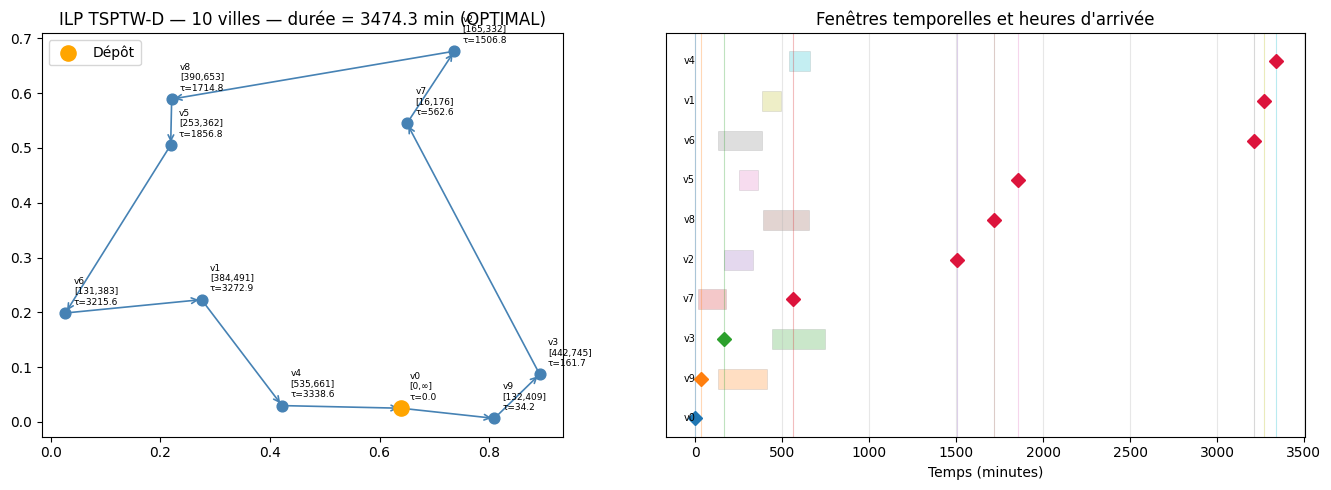

In [9]:
# ── Test rapide sur graphe aléatoire avec fenêtres et perturbations ───────────

rng = random.Random(SEED)
cities_demo = generate_graph(N_CITIES, seed=SEED)

# Fenêtres temporelles aléatoires [a_i, b_i] en minutes
tw_demo = [(0.0, float("inf"))]   # dépôt : toujours ouvert
for _ in range(N_CITIES - 1):
    a = rng.uniform(0, 600)
    b = a + rng.uniform(100, 400)
    tw_demo.append((a, b))

# Temps de service : 5 à 20 minutes par ville
st_demo = [0.0] + [rng.uniform(5, 20) for _ in range(N_CITIES - 1)]

# Une perturbation aléatoire
i_p, j_p = rng.sample(range(N_CITIES), 2)
pert_demo = [
    {"arc": [i_p, j_p], "t_start": 100.0, "t_end": 400.0, "alpha": 2.5}
]

print(f"Instance aléatoire : {N_CITIES} villes, SCALE={SCALE}, HORIZON={HORIZON} min")
print(f"Perturbation : arc ({i_p},{j_p}) × 2.5 de t=100 à t=400\n")

t0 = time.perf_counter()
tour_r, dur_r, status_r, arr_r = solve_tsp_ilp_tsptwd(
    cities_demo,
    time_windows=tw_demo,
    service_times=st_demo,
    perturbations=pert_demo,
    scale=SCALE,
    horizon=HORIZON,
    time_limit=TIME_LIMIT,
)
elapsed_r = time.perf_counter() - t0

print(f"Statut   : {status_r}")
print(f"Durée    : {dur_r:.1f} min (τ_retour)")
if tour_r:
    print(f"Tour     : {' → '.join(f'v{c}' for c in tour_r + [tour_r[0]])}")
print(f"Temps    : {elapsed_r:.2f}s")

if tour_r:
    plot_tour_tsptwd_ilp(
        cities_demo, tour_r, tw_demo, arr_r,
        perturbations=pert_demo,
        title=f"ILP TSPTW-D — {N_CITIES} villes — durée = {dur_r:.1f} min ({status_r})",
        scale=SCALE,
    )


## 7. Exécution — instance JSON (datasets/)

Instance : tsptwd_n10.json
Perturbations : [{'arc': [7, 10], 't_start': 630.5, 't_end': 876.1, 'alpha': 3.45}, {'arc': [0, 3], 't_start': 327.1, 't_end': 579.0, 'alpha': 3.16}]

Statut   : OPTIMAL
Durée    : 6303.3 min (τ_retour)
Temps    : 0.11s


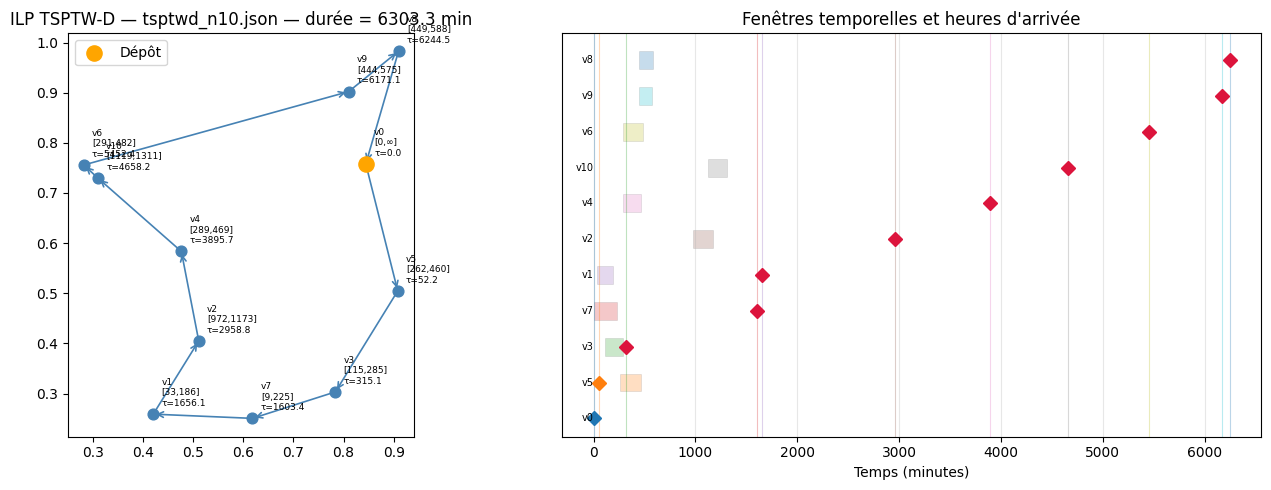

In [10]:
# ── Test sur instance JSON (même datasets que le LKH-3) ──────────────────────

DATASETS_DIR = Path("datasets")
demo_path = next(DATASETS_DIR.glob("tsptwd_n10.json"), None)
if demo_path is None:
    demo_path = next(DATASETS_DIR.glob("tsptwd_n*.json"), None)

if demo_path:
    coords_j, tw_j, st_j, pert_j, meta_j = load_json_instance(demo_path)
    scale_j  = meta_j["scale"]
    horizon_j = meta_j.get("horizon", float("inf"))

    print(f"Instance : {demo_path.name}")
    print(f"Perturbations : {pert_j}\n")

    t0 = time.perf_counter()
    tour_j, dur_j, status_j, arr_j = solve_tsp_ilp_tsptwd(
        coords_j,
        time_windows=tw_j,
        service_times=st_j,
        perturbations=pert_j,
        scale=scale_j,
        horizon=horizon_j,
        time_limit=TIME_LIMIT,
    )
    elapsed_j = time.perf_counter() - t0

    print(f"Statut   : {status_j}")
    print(f"Durée    : {dur_j:.1f} min (τ_retour)")
    #print(f"Tour     : {' → '.join(f'v{c}' for c in tour_j + [tour_j[0]])}")
    print(f"Temps    : {elapsed_j:.2f}s")

    if tour_j:
        plot_tour_tsptwd_ilp(
            coords_j, tour_j, tw_j, arr_j,
            perturbations=pert_j,
            title=f"ILP TSPTW-D — {demo_path.name} — durée = {dur_j:.1f} min",
            scale=scale_j,
        )
else:
    print("Aucun dataset JSON trouvé dans ./datasets/ — utilise le test aléatoire ci-dessus.")


## 8. Formulation DFJ avec lazy constraints — TSPTW-D


=== DFJ TSPTW-D — tsptwd_n10.json ===

  Itération  1 — 1 cycle(s) → tour unique ✓
Durée    : 6303.3 min | 1 iter | 0 coupes | 0.11s


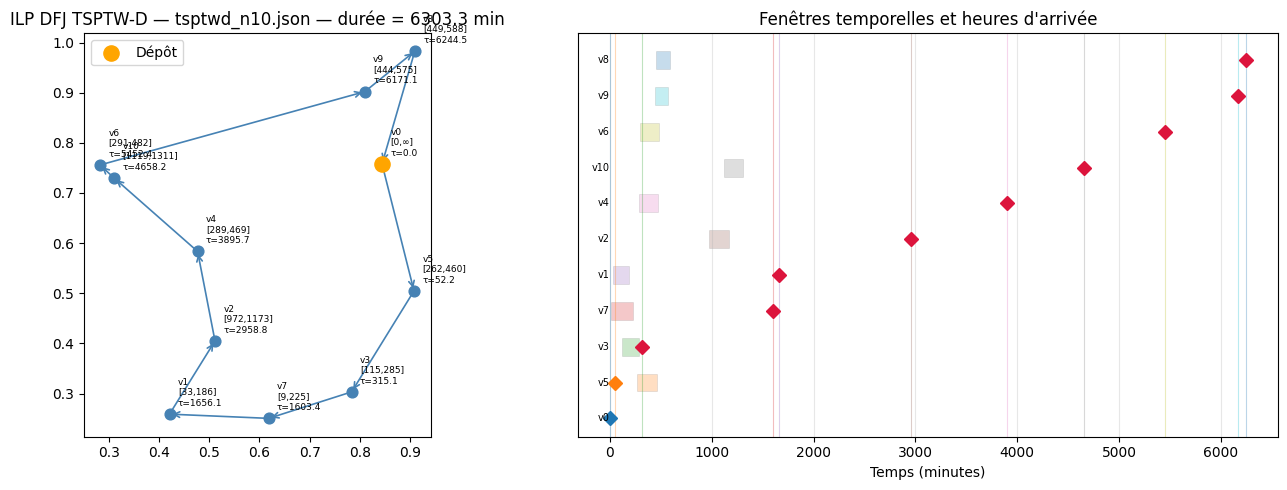

In [11]:
# ── Formulation DFJ avec lazy constraints — TSPTW-D ──────────────────────────

def find_subtours(n, x_val):
    """Détecte tous les sous-tours dans une solution binaire."""    
    visited = [False] * n
    subtours = []
    for start in range(n):
        if visited[start]:
            continue
        tour, current = [], start
        while not visited[current]:
            visited[current] = True
            tour.append(current)
            nxt = next((j for j in range(n) if x_val[current][j] > 0.5), None)
            if nxt is None:
                break
            current = nxt
        subtours.append(tour)
    return subtours


def solve_tsptwd_dfj(
    cities,
    time_windows=None,
    service_times=None,
    perturbations=None,
    scale=1.0,
    horizon=float("inf"),
    time_limit=120.0,
):
    """
    TSPTW-D exact via ILP DFJ avec lazy constraints + contraintes temporelles.
    Plus efficace que MTZ pour les instances > 20 villes.
    """
    n = len(cities)
    INF = float("inf")

    if time_windows is None:
        time_windows = [(0.0, INF)] * n
    if service_times is None:
        service_times = [0.0] * n
    if perturbations is None:
        perturbations = []

    cost_int, dep_by_city = build_cost_matrix(
        cities, time_windows, service_times, perturbations, scale, horizon
    )

    max_cost = max(cost_int[i][j] for i in range(n) for j in range(n) if i != j)
    BIG_M_time = int(n * max_cost / 1000) + (int(2 * horizon) if horizon < INF else 0) + 1
    SCALE_T    = 100
    tau_max    = int(BIG_M_time * SCALE_T)
    BIG_M_int  = tau_max

    forbidden = []
    iteration = 0

    while True:
        iteration += 1
        model = cp_model.CpModel()
        x = [[model.new_bool_var(f"x_{i}_{j}") for j in range(n)] for i in range(n)]
        tau = [model.new_int_var(0, tau_max, f"tau_{i}") for i in range(n)]

        # Contraintes de degré
        for i in range(n):
            model.add(x[i][i] == 0)
            model.add(sum(x[i][j] for j in range(n) if j != i) == 1)
            model.add(sum(x[j][i] for j in range(n) if j != i) == 1)

        # Coupes DFJ accumulées
        for S in forbidden:
            S_list = list(S)
            model.add(sum(x[i][j] for i in S_list for j in S_list if i != j) <= len(S_list) - 1)

        # Contraintes temporelles
        model.add(tau[0] == 0)
        for i in range(n):
            s_i_int = int(service_times[i] * SCALE_T)
            for j in range(1, n):
                if i == j:
                    continue
                c_ij_int = int(cost_int[i][j] * SCALE_T / 1000)
                model.add(tau[j] >= tau[i] + s_i_int + c_ij_int - BIG_M_int * (1 - x[i][j]))

        # Objectif avec pénalité fenêtres
        obj_dist = sum(cost_int[i][j] * x[i][j] for i in range(n) for j in range(n) if i != j)
        penalty_terms = []
        for i in range(1, n):
            a_i, b_i = time_windows[i]
            if b_i < INF:
                b_i_int = int(b_i * SCALE_T)
                surplus = model.new_int_var(0, tau_max, f"surplus_{i}")
                model.add(surplus >= tau[i] - b_i_int)
                model.add(surplus >= 0)
                penalty_terms.append(surplus)

        if penalty_terms:
            model.minimize(obj_dist + (n + 1) * sum(penalty_terms))
        else:
            model.minimize(obj_dist)

        solver = cp_model.CpSolver()
        solver.parameters.max_time_in_seconds = time_limit
        status_code = solver.solve(model)

        if status_code not in (cp_model.OPTIMAL, cp_model.FEASIBLE):
            return [], float("inf"), [], iteration, len(forbidden), "INFEASIBLE"

        x_val = [[solver.value(x[i][j]) for j in range(n)] for i in range(n)]
        subtours = find_subtours(n, x_val)
        print(f"  Itération {iteration:>2} — {len(subtours)} cycle(s)", end="")

        if len(subtours) == 1:
            print(" → tour unique ✓")
            break

        new_cuts = 0
        for st in subtours:
            fs = frozenset(st)
            if fs not in forbidden and len(fs) < n:
                forbidden.append(fs)
                new_cuts += 1
        print(f" — {new_cuts} coupe(s) (total : {len(forbidden)})")

    tour = subtours[0]
    # Recalcul durée réelle avec fenêtres cycliques
    arr_times = []
    t = 0.0
    route = tour + [tour[0]]
    for k in range(len(route) - 1):
        city = route[k]
        a_i, b_i = time_windows[city]
        s_i = service_times[city]
        dep = next_service_time(t, a_i, b_i, s_i, horizon)
        arr_times.append(t)
        j = route[k + 1]
        travel = dynamic_cost(cities, city, j, dep, perturbations, scale)
        t = dep + travel
    arr_times.append(t)

    total = sum(cost_int[tour[k]][tour[k+1]] for k in range(n-1))
    total += cost_int[tour[-1]][tour[0]]
    total /= 1000

    return tour, t, arr_times, iteration, len(forbidden), "OPTIMAL"


# ── Test DFJ TSPTW-D ─────────────────────────────────────────────────────────
if demo_path:
    print(f"\n=== DFJ TSPTW-D — {demo_path.name} ===\n")
    t0 = time.perf_counter()
    tour_dfj, dur_dfj, arr_dfj, iters, cuts, st_dfj = solve_tsptwd_dfj(
        coords_j, time_windows=tw_j, service_times=st_j,
        perturbations=pert_j, scale=scale_j, horizon=horizon_j,
        time_limit=TIME_LIMIT,
    )
    elapsed_dfj = time.perf_counter() - t0
    print(f"Durée    : {dur_dfj:.1f} min | {iters} iter | {cuts} coupes | {elapsed_dfj:.2f}s")
    if tour_dfj:
        plot_tour_tsptwd_ilp(
            coords_j, tour_dfj, tw_j, arr_dfj,
            perturbations=pert_j,
            title=f"ILP DFJ TSPTW-D — {demo_path.name} — durée = {dur_dfj:.1f} min",
            scale=scale_j,
        )


## 9. Benchmark TSPTW-D sur les datasets JSON

In [12]:
# ── Benchmark TSPTW-D sur les datasets JSON ───────────────────────────────────

def benchmark_datasets_ilp(datasets_dir, skip_n=50, time_limit=30.0):
    """
    Exécute solve_tsp_ilp_tsptwd sur toutes les instances JSON.
    Compare avec le solveur MTZ de base (sans contraintes TSPTW-D).
    """
    files = sorted(
        datasets_dir.glob("tsptwd_n*.json"),
        key=lambda p: int(p.stem.split("_n")[1]),
    )
    rows = []
    for path in files:
        coords_b, tw_b, st_b, pert_b, meta_b = load_json_instance(path)
        n = meta_b["n_clients"]
        if n >= skip_n:
            print(f"  n={n:>6}  [SKIP]")
            continue

        scale_b   = meta_b["scale"]
        horizon_b = meta_b.get("horizon", float("inf"))

        t0 = time.perf_counter()
        tour_b, dur_b, status_b, arr_b = solve_tsp_ilp_tsptwd(
            coords_b, time_windows=tw_b, service_times=st_b,
            perturbations=pert_b, scale=scale_b, horizon=horizon_b,
            time_limit=time_limit,
        )
        elapsed_b = time.perf_counter() - t0

        print(
            f"  n={n:>6}  ILP={dur_b:>9.1f} min  {status_b:<10}  t={elapsed_b:.2f}s"
        )
        rows.append({
            "n":           n,
            "dur_ilp_min": round(dur_b, 1),
            "status":      status_b,
            "elapsed_s":   round(elapsed_b, 3),
        })

    import pandas as pd
    return pd.DataFrame(rows).set_index("n") if rows else None


DATASETS_DIR = Path("datasets")
if DATASETS_DIR.exists():
    print("=== Benchmark ILP TSPTW-D ===\n")
    df_ilp = benchmark_datasets_ilp(DATASETS_DIR, skip_n=30, time_limit=30.0)
    if df_ilp is not None:
        print()
        print(df_ilp)
else:
    print("Dossier datasets/ introuvable — lance les tests sur graphes aléatoires.")


=== Benchmark ILP TSPTW-D ===

  n=     5  ILP=   1367.7 min  OPTIMAL     t=0.06s
  n=    10  ILP=   6303.3 min  OPTIMAL     t=0.11s
  n=    50  [SKIP]
  n=   100  [SKIP]
  n=   200  [SKIP]
  n=   300  [SKIP]
  n=   500  [SKIP]
  n=  1000  [SKIP]
  n= 10000  [SKIP]

    dur_ilp_min   status  elapsed_s
n                                  
5        1367.7  OPTIMAL      0.055
10       6303.3  OPTIMAL      0.108


## 10. Complexité de l'ILP

### Pourquoi le TSP (et le TSPTW-D) est NP-difficile

Le TSP appartient à la classe **NP-difficile** : aucun algorithme polynomial n'est connu pour le résoudre de façon exacte, sauf si P = NP.

| Aspect | Valeur |
|---|---|
| Nombre de tournées possibles | $(n-1)!/2$ |
| Pour $n = 20$ | $\approx 6 \times 10^{16}$ tournées |
| Complexité brute force | $O(n!)$ |
| Programmation dynamique (Held-Karp) | $O(n^2 \cdot 2^n)$ |

### Complexité de la formulation ILP (MTZ)

La formulation MTZ introduit $O(n^2)$ variables binaires et $O(n^2)$ contraintes MTZ.  
En pratique, le branch-and-bound résout l'ILP en temps **exponentiel dans le pire cas** :

$$T_{\text{ILP}} = O\!\left(2^{O(n^2)}\right) \quad \text{(pire cas branch-and-bound)}$$

Les solveurs modernes (CP-SAT, Gurobi) utilisent des coupes (Gomory, Chvátal-Gomory) et du *presolving* pour réduire l'arbre de recherche, mais **la garantie reste exponentielle en général**.

### Impact des contraintes TSPTW-D

L'ajout des **fenêtres temporelles** et des **coûts dynamiques** renforce la propagation (arc consistency) et peut *réduire* l'espace de recherche effectif sur les instances structurées — mais n'améliore pas la complexité dans le pire cas.

**Conclusion pratique :** l'ILP reste exact et fiable pour $n \leq 15$–$20$ sur ce problème. Au-delà, les métaheuristiques (LKH-3, SMA, POPMUSIC) ou l'apprentissage profond (GNN) offrent de meilleures garanties de temps d'exécution.

## 11. Lower bound 1-tree et ratio qualité

In [ ]:
def one_tree_lb(cities, perturbations=None, scale=1.0):
    """
    Calcule le 1-tree lower bound (borne inférieure de Held-Karp).

    Définition :
        1-tree LB = MST sur les nœuds {1..n-1} + 2 arêtes minimales depuis le dépôt (nœud 0).

    Utilise les coûts de base (sans perturbations temporelles) pour la borne inférieure,
    ce qui reste une borne valide car les perturbations ne font qu'augmenter les coûts.
    """
    perturbations = perturbations or []
    n = len(cities)
    if n < 2:
        return 0.0

    # Coûts de base (t=0, avant perturbations)
    def dist(i, j):
        return dynamic_cost(cities, i, j, 0.0, perturbations, scale)

    # MST de Prim sur les nœuds {1..n-1}
    if n == 2:
        mst_cost = 0.0
    else:
        in_mst = [False] * n
        key = [float("inf")] * n
        in_mst[1] = True
        key[1] = 0.0
        for j in range(2, n):
            key[j] = dist(1, j)

        mst_cost = 0.0
        for _ in range(n - 3):  # n-2 nœuds à ajouter (sans dépôt 0)
            # Choisir le nœud non-MST avec clé minimale (parmi {1..n-1})
            u = min(
                (v for v in range(1, n) if not in_mst[v]),
                key=lambda v: key[v],
                default=None,
            )
            if u is None:
                break
            in_mst[u] = True
            mst_cost += key[u]
            for v in range(1, n):
                if not in_mst[v]:
                    d = dist(u, v)
                    if d < key[v]:
                        key[v] = d

        # Ajouter le dernier nœud
        remaining = [v for v in range(1, n) if not in_mst[v]]
        for v in remaining:
            mst_cost += key[v]

    # 2 arêtes minimales depuis le dépôt (nœud 0) vers les nœuds {1..n-1}
    edges_from_depot = sorted(dist(0, j) for j in range(1, n))
    depot_contribution = sum(edges_from_depot[:2]) if len(edges_from_depot) >= 2 else sum(edges_from_depot)

    return mst_cost + depot_contribution


def feasibility_check(tour, arrival_times, time_windows):
    """Vérifie que toutes les fenêtres temporelles sont respectées (arrivée <= b_i)."""
    for rank, city in enumerate(tour):
        a_i, b_i = time_windows[city]
        if rank < len(arrival_times):
            arr = arrival_times[rank]
            if b_i < float("inf") and arr > b_i + 1e-6:
                return False
    return True


## 12. Export format uniforme — `results/ilp_results.csv`

In [ ]:
import pandas as pd

def benchmark_ilp_export(datasets_dir, skip_n=20, time_limit=30.0):
    """
    Benchmark ILP sur les datasets JSON et export au format uniforme inter-notebooks.

    Schéma de sortie :
        algo, n, run, makespan, ratio_lb, time_ms, feasible
    """
    files = sorted(
        Path(datasets_dir).glob("tsptwd_n*.json"),
        key=lambda p: int(p.stem.split("_n")[1]),
    )
    rows = []
    for path in files:
        coords_b, tw_b, st_b, pert_b, meta_b = load_json_instance(path)
        n = meta_b["n_clients"]
        if n >= skip_n:
            print(f"  n={n:>6}  [SKIP — trop grand pour ILP exact]")
            continue

        scale_b   = meta_b["scale"]
        horizon_b = meta_b.get("horizon", float("inf"))

        lb = one_tree_lb(coords_b, pert_b, scale_b)

        t0 = time.perf_counter()
        tour_b, makespan_b, status_b, arr_b = solve_tsp_ilp_tsptwd(
            coords_b, time_windows=tw_b, service_times=st_b,
            perturbations=pert_b, scale=scale_b, horizon=horizon_b,
            time_limit=time_limit,
        )
        elapsed_ms = (time.perf_counter() - t0) * 1000

        ratio = makespan_b / lb if lb > 0 and makespan_b < float("inf") else float("nan")
        feasible = feasibility_check(tour_b, arr_b, tw_b) if tour_b else False

        print(
            f"  n={n:>6}  makespan={makespan_b:>9.1f} min  "
            f"LB={lb:>8.1f}  ratio={ratio:.3f}  {status_b:<10}  t={elapsed_ms/1000:.2f}s"
        )
        rows.append({
            "algo":     "ilp",
            "n":        n,
            "run":      0,
            "makespan": round(makespan_b, 2),
            "ratio_lb": round(ratio, 4),
            "time_ms":  round(elapsed_ms, 1),
            "feasible": feasible,
        })

    df = pd.DataFrame(rows)
    if not df.empty:
        out_dir = Path("results")
        out_dir.mkdir(exist_ok=True)
        out_path = out_dir / "ilp_results.csv"
        df.to_csv(out_path, index=False)
        print(f"\n✓ Résultats exportés → {out_path}")
    return df


DATASETS_DIR = Path("datasets")
if DATASETS_DIR.exists():
    print("=== Benchmark ILP — export format uniforme ===\n")
    df_export = benchmark_ilp_export(DATASETS_DIR, skip_n=20, time_limit=30.0)
    if not df_export.empty:
        print()
        print(df_export.to_string(index=False))
else:
    print("Dossier datasets/ introuvable.")
